# EDA & Results — ATP Match Prediction

Companion notebook to [`wimbledon_qf_prediction.ipynb`](wimbledon_qf_prediction.ipynb):
here we look at the **raw data and preprocessing** in more depth — coverage, missing
values, upset rates, the Elo engine at work — and then the **model results**.

Run order: `data/download_data.sh` first (fetches the CSVs; optionally
`src/ingest_api.py` to add the live Feb–Jul 2026 supplement), then this notebook
top-to-bottom. Everything imports from `../src`.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# palette: fixed categorical order (blue, aqua, yellow, green, violet, red)
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
mpl.rcParams.update({
    "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "figure.dpi": 110,
})

from features import load_matches, build_dataset, PlayerBook, FEATURES, SURFACES
df = load_matches()
print(f"{len(df):,} matches | {df.tourney_date.min():%Y-%m-%d} -> {df.tourney_date.max():%Y-%m-%d} "
      f"| {pd.concat([df.winner_name, df.loser_name]).nunique():,} players")
df.head(3)

71,141 matches | 2000-01-03 -> 2026-07-06 | 1,826 players


,tourney_id,tourney_name,surface,draw_size,tourney_level,indoor,tourney_date,match_num,winner_id,winner_seed,...,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced
0,2000-451,Doha,Hard,32.0,250,O,2000-01-03,1.0,K316,1.0,...,3.0,5.0,2.0,83.0,53.0,36.0,17.0,12.0,2.0,4.0
1,2000-451,Doha,Hard,32.0,250,O,2000-01-03,2.0,C270,NaN,...,14.0,8.0,5.0,102.0,57.0,41.0,18.0,16.0,2.0,7.0
2,2000-451,Doha,Hard,32.0,250,O,2000-01-03,3.0,S568,NaN,...,3.0,3.0,5.0,63.0,38.0,28.0,6.0,9.0,5.0,9.0


## 1 — What the raw data looks like

One row per completed tour-level match. The columns split into tournament context
(`tourney_*`, `surface`, `round`), player attributes (`*_rank`, `*_age`, `*_ht`) and
in-match stats (`w_ace`, `w_svpt`, ...). First: where are the holes?

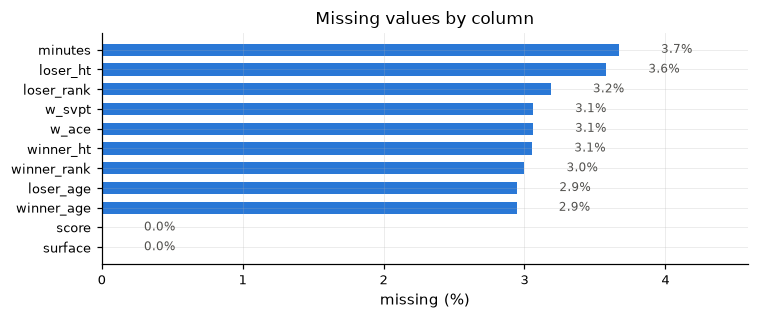

In [2]:
cols = ["winner_rank","loser_rank","winner_age","loser_age","winner_ht","loser_ht",
        "minutes","w_ace","w_svpt","score","surface"]
miss = df[cols].isna().mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(miss.index, miss.values, color=C[0], height=.62)
for yv, v in enumerate(miss.values):
    ax.text(v + .3, yv, f"{v:.1f}%", va="center", fontsize=8, color="#52514e")
ax.set_xlabel("missing (%)"); ax.set_title("Missing values by column")
ax.set_xlim(0, max(miss.values) * 1.25)
plt.tight_layout()

Ranks, ages and heights are near-complete — good, they feed features directly.
In-match serve stats have a few percent missing (mostly older or lower-tier events);
we don't use them in v1, and match `minutes` gaps are why fatigue features need the
API rather than this feed.

### Coverage by season and surface

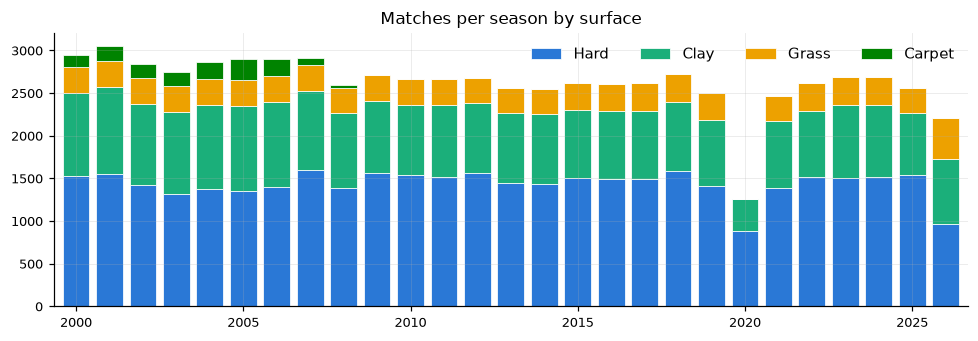

In [3]:
per = (df.assign(year=df.tourney_date.dt.year)
         .groupby(["year","surface"]).size().unstack(fill_value=0)
         .reindex(columns=["Hard","Clay","Grass","Carpet"]))
fig, ax = plt.subplots(figsize=(9, 3.2))
bottom = np.zeros(len(per))
for i, s in enumerate(per.columns):
    ax.bar(per.index, per[s], bottom=bottom, label=s, color=C[i], width=.8,
           edgecolor="white", linewidth=.5)
    bottom += per[s].values
ax.legend(ncol=4, loc="upper right")
ax.set_title("Matches per season by surface")
ax.margins(x=.01)
plt.tight_layout()

Steady ~2.7–2.9k matches per season; carpet disappears after 2008 (the tour retired
the surface); the dips are the 2020 COVID season and 2026 being **half a season** —
January from the yearly CSVs plus the api-tennis.com supplement through 7 July
(one hole remains: the Jan 19–31 Australian Open window falls between the two sources).

### How often does the favourite actually win?

Our target is hard by nature: the lower-ranked player wins a *lot* of tennis matches.

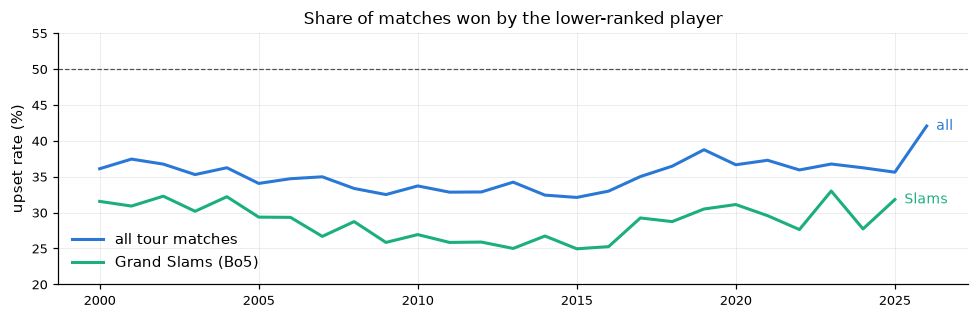

In [4]:
ok = df.dropna(subset=["winner_rank","loser_rank"]).copy()
ok["upset"] = ok.winner_rank > ok.loser_rank
by_year = ok.groupby(ok.tourney_date.dt.year)["upset"].mean() * 100
slams = ok[ok.tourney_level == "G"]
by_year_slam = slams.groupby(slams.tourney_date.dt.year)["upset"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(by_year.index, by_year.values, color=C[0], lw=2, label="all tour matches")
ax.plot(by_year_slam.index, by_year_slam.values, color=C[1], lw=2, label="Grand Slams (Bo5)")
ax.axhline(50, color="#52514e", lw=.8, ls="--")
ax.text(by_year.index[-1] + .3, by_year.values[-1], "all", color=C[0], fontsize=9, va="center")
ax.text(by_year_slam.index[-1] + .3, by_year_slam.values[-1], "Slams", color=C[1], fontsize=9, va="center")
ax.set_ylabel("upset rate (%)"); ax.set_ylim(20, 55)
ax.set_title("Share of matches won by the lower-ranked player")
ax.legend(loc="lower left")
plt.tight_layout()

A third of all matches are "upsets" by ranking — so 100% accuracy is a fantasy
and ~64–70% is the realistic ceiling. Slams have visibly fewer upsets: best-of-five
favours the stronger player, which is why `best_of_5` is a model feature (and mildly
helps Djokovic today).

## 2 — Preprocessing: the Elo engine

The core preprocessing step replays all matches chronologically, maintaining running
Elo per player (overall + per surface). Here we instrument that replay to watch our
two quarter-finalists' ratings evolve:

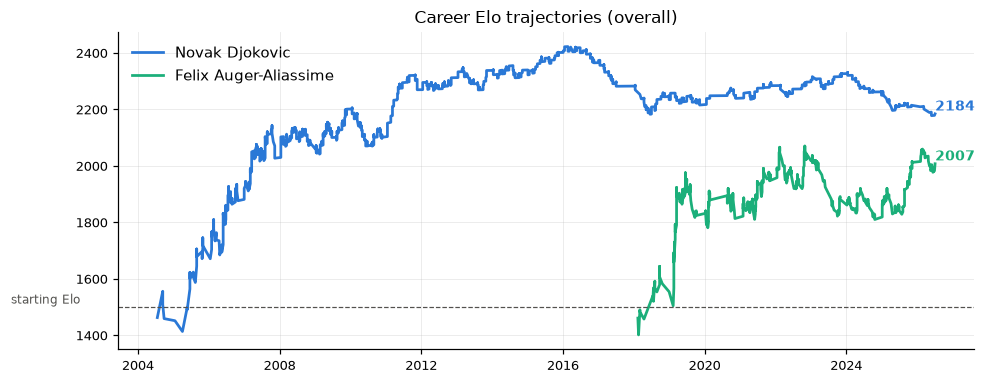

In [5]:
book = PlayerBook()
track = {"Novak Djokovic": [], "Felix Auger-Aliassime": []}
for m in df.itertuples(index=False):
    surface = m.surface if m.surface in SURFACES else "Hard"
    book.update(m.winner_name, m.loser_name, surface, m.tourney_level == "G")
    for p in track:
        if p in (m.winner_name, m.loser_name):
            track[p].append((m.tourney_date, book.elo[p], book.surface_elo["Grass"][p]))

fig, ax = plt.subplots(figsize=(9, 3.6))
for i, (p, hist) in enumerate(track.items()):
    h = pd.DataFrame(hist, columns=["date","elo","grass_elo"])
    ax.plot(h.date, h.elo, color=C[i], lw=1.8, label=p)
    ax.text(h.date.iloc[-1], h.elo.iloc[-1] + 12, f"{h.elo.iloc[-1]:.0f}",
            color=C[i], fontsize=9, fontweight="bold")
ax.axhline(1500, color="#52514e", lw=.8, ls="--")
ax.text(pd.Timestamp("2000-06-01"), 1512, "starting Elo", fontsize=8, color="#52514e")
ax.set_title("Career Elo trajectories (overall)")
ax.legend(loc="upper left")
plt.tight_layout()

The rating tells the career story on its own: Djokovic's climb from his 2004-05
debut to a dominant plateau above 2200, and Auger-Aliassime's rise to a solid but
clearly lower band around 2000. The ~180-point gap is the single biggest input to the
prediction — Elo alone converts it to `1/(1+10^(-177/400))` ≈ **73%**, which the full
model tempers to ~67% with form, rank and age.

### From replay to training matrix

`build_dataset()` runs the same replay but *snapshots state before each update*, so
every row only knows the past. Output: 9 symmetric difference-features per match.

61,127 rows x 9 features | base rate P(p1 wins) = 0.503


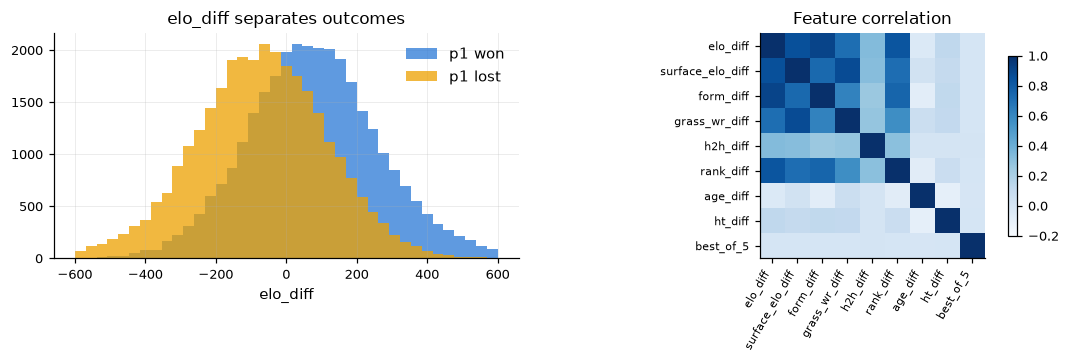

In [6]:
X, y, meta, book = build_dataset()
print(f"{X.shape[0]:,} rows x {X.shape[1]} features | base rate P(p1 wins) = {y.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
bins = np.linspace(-600, 600, 40)
axes[0].hist(X.elo_diff[y==1], bins=bins, alpha=.75, color=C[0], label="p1 won")
axes[0].hist(X.elo_diff[y==0], bins=bins, alpha=.75, color=C[2], label="p1 lost")
axes[0].set_title("elo_diff separates outcomes"); axes[0].set_xlabel("elo_diff")
axes[0].legend()

corr = X.corr().values
im = axes[1].imshow(corr, cmap="Blues", vmin=-.2, vmax=1)
axes[1].set_xticks(range(len(FEATURES)), FEATURES, rotation=60, ha="right", fontsize=7)
axes[1].set_yticks(range(len(FEATURES)), FEATURES, fontsize=7)
axes[1].set_title("Feature correlation"); axes[1].grid(False)
fig.colorbar(im, ax=axes[1], shrink=.8)
plt.tight_layout()

Left: the label distributions are mirror-shifted around zero — Elo difference
carries real signal, but the overlap is exactly why tennis prediction tops out in the
60s. Right: `elo_diff`, `surface_elo_diff` and `rank_diff` are correlated (they all
measure "who's better") but far from redundant; the tree model can exploit the
disagreements, e.g. a grass specialist under-ranked on overall Elo.

## 3 — Results

Chronological split — train 2000–21, validate 2022–23 (model choice), test 2024–26
(reported once):

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

year = meta.date.dt.year
tr, va, te = year <= 2021, (year >= 2022) & (year <= 2023), year >= 2024

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X[tr], y[tr])
gbdt = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.06, max_iter=400,
                                      l2_regularization=1.0, random_state=7).fit(X[tr], y[tr])
print(f"val log-loss  logreg {log_loss(y[va], logreg.predict_proba(X[va])[:,1]):.4f}"
      f" | gbdt {log_loss(y[va], gbdt.predict_proba(X[va])[:,1]):.4f}  -> gbdt selected")
best = gbdt

elo_p = 1/(1 + 10**(-X.loc[te,"elo_diff"]/400))
rows = []
for name, p in [("higher-rank baseline", (X.loc[te,"rank_diff"]>0).to_numpy().astype(float)),
                ("Elo-only baseline", elo_p.to_numpy()),
                ("gradient boosting", best.predict_proba(X[te])[:,1])]:
    rows.append({"model": name, "accuracy": accuracy_score(y[te], p>=.5),
                 "log_loss": log_loss(y[te], p) if len(np.unique(p))>2 else float("nan"),
                 "roc_auc": roc_auc_score(y[te], p)})
pd.DataFrame(rows).round(4)

val log-loss  logreg 0.6193 | gbdt 0.6184  -> gbdt selected


,model,accuracy,log_loss,roc_auc
0,higher-rank baseline,0.6039,NaN,0.6034
1,Elo-only baseline,0.6318,0.6411,0.6904
2,gradient boosting,0.6370,0.6243,0.7012


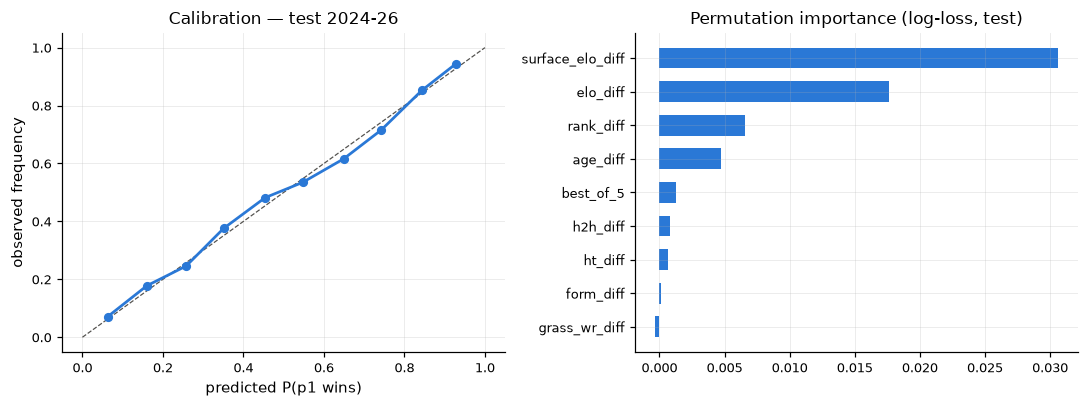

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
proba_te = best.predict_proba(X[te])[:,1]
frac, mean = calibration_curve(y[te], proba_te, n_bins=10)
axes[0].plot([0,1],[0,1], ls="--", c="#52514e", lw=.8)
axes[0].plot(mean, frac, "o-", color=C[0], ms=5, lw=1.8)
axes[0].set_xlabel("predicted P(p1 wins)"); axes[0].set_ylabel("observed frequency")
axes[0].set_title("Calibration — test 2024-26")

imp = permutation_importance(best, X[te], y[te], n_repeats=5, random_state=7,
                             scoring="neg_log_loss")
order = imp.importances_mean.argsort()
axes[1].barh(np.array(FEATURES)[order], imp.importances_mean[order], color=C[0], height=.62)
axes[1].set_title("Permutation importance (log-loss, test)")
plt.tight_layout()

Calibration hugs the diagonal — when the model says 70%, the favourite wins
about 70% of the time, so the output probabilities are trustworthy as *odds*, not
just rankings. Importance confirms the Elo pair does most of the work, with rank and
form adding the rest.

### The quarter-final

,player,elo,grass elo,form (L25),P(win)
0,Novak Djokovic,2184.2,2202.8,0.76,66.8%
1,Felix Auger-Aliassime,2007.4,1778.6,0.64,33.2%


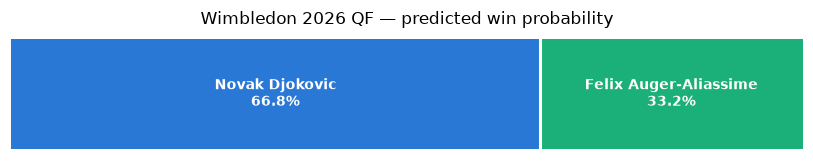

In [9]:
best.fit(X, y)   # refit on everything before predicting

P1, P2 = "Novak Djokovic", "Felix Auger-Aliassime"
s1, s2 = book.snapshot(P1, "Grass"), book.snapshot(P2, "Grass")
row = pd.DataFrame([[s1["elo"]-s2["elo"], s1["surface_elo"]-s2["surface_elo"],
                     s1["form"]-s2["form"], s1["surface_wr"]-s2["surface_wr"],
                     book.h2h[(P1,P2)]-book.h2h[(P2,P1)],
                     np.log2(3)-np.log2(7), 39.1-25.9, 188-193, 1]], columns=FEATURES)
p = float(best.predict_proba(row)[0,1])

fig, ax = plt.subplots(figsize=(7.5, 1.6))
ax.barh([0],[p], color=C[0]); ax.barh([0],[1-p], left=[p], color=C[1])
ax.axvline(p, color="white", lw=2)
ax.text(p/2, 0, f"{P1}\n{p:.1%}", ha="center", va="center", color="white", fontweight="bold", fontsize=9)
ax.text(p+(1-p)/2, 0, f"{P2}\n{1-p:.1%}", ha="center", va="center", color="white", fontweight="bold", fontsize=9)
ax.set_xlim(0,1); ax.axis("off")
ax.set_title("Wimbledon 2026 QF — predicted win probability", fontsize=11)
plt.tight_layout()

pd.DataFrame({"player":[P1,P2],
              "elo":[round(s1['elo'],1), round(s2['elo'],1)],
              "grass elo":[round(s1['surface_elo'],1), round(s2['surface_elo'],1)],
              "form (L25)":[s1['form'], s2['form']],
              "P(win)":[f"{p:.1%}", f"{1-p:.1%}"]})

## Takeaways

- The data is clean enough to model directly: ranks/ages/heights near-complete,
  ~59k usable feature rows after the cold-start filter.
- **Upsets are structural** (~33% of matches), capping realistic accuracy in the
  60s; our 63.7% / 0.624 log-loss beats both baselines and is well calibrated.
- The Elo replay is the heart of preprocessing — and its ~180-point Djokovic edge,
  moderated by form/rank/age features, lands on **Djokovic ≈ 67% / Auger-Aliassime ≈ 33%**.
- Counterintuitive but true: backfilling the live 2026 season via the API moved the
  prediction *toward* Djokovic (62% → 67%) — Auger-Aliassime's raw 2026 form (64% of
  his last 25) is weaker than his 3-seed suggests, while Djokovic's grass rating held.